<a href="https://colab.research.google.com/github/anu-raj-16/Predictive-Health-Model-Coronary-Artery-Disease/blob/main/Predictive_Health_Model_Coronary_Artery_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Interpretable Machine Learning for Cardiovascular Risk Assessment
**Name:** Anagha Gururaj |
**Objective:** To develop a predictive model for coronary artery disease using clinical biomarkers, prioritizing model interpretability (Explainable AI) for clinical decision support.



## 1. Data Acquisition and Clinical Pre-processing
We utilize the **UCI Cleveland Heart Disease dataset**.
* **Data Cleaning:** Handling missing values (`?`) through listwise deletion to maintain data integrity.
* **Target Engineering:** Converting multi-class diagnosis (Stages 0-4) into a binary classification (Healthy vs. Disease) to align with clinical screening protocols.


In [ ]:
import pandas as pd
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv(url, names=names, na_values="?")
df = df.dropna()
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,1
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,1
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


## 2. Feature Engineering & Dimensionality
Clinical data often contains categorical variables (e.g., Chest Pain Type) that are non-ordinal.
* **One-Hot Encoding:** We expand categorical features into dummy variables to prevent the model from assuming a false numerical ranking.
* **Standardization:** Utilizing `StandardScaler` to normalize features like `cholesterol` and `blood pressure` to a common scale, ensuring feature-weight neutrality.


In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.model_selection import train_test_split

df_encoded = pd.get_dummies(df, columns=['sex', 'cp', 'fbs', 'restecg', 'slope', 'exang', 'thal'], drop_first=True)
df_encoded.head(10)
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## 3. Model Implementation
We selected Logistic Regression due to the limited sample size (n = 303), as its linear decision boundary minimizes the risk of overfitting. It provides high coefficients for feature interpretability, which is essential for clinical validation and aligning model outputs with known physiological risk factors.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

acc = accuracy_score(y_test, model.predict(X_test))
print(f"Final Accuracy: {acc * 100:.2f}%")

Final Accuracy: 88.33%


## 3.1. Statistical Feature Weights
To quantify the direct relationship between clinical inputs and diagnosis, we extract the model's coefficients. These represent the "log-odds" contribution of each feature, allowing us to rank biomarkers by their statistical significance in the predictive process.

In [ ]:
import numpy as np

feature_names = X.columns

coefficients = model.coef_.flatten()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

importance_df['Abs_Coefficient'] = importance_df['Coefficient'].abs()
importance_df = importance_df.sort_values(by='Abs_Coefficient', ascending=False)

print("Top Clinical Predictors (Logistic Regression Coefficients):")
print(importance_df[['Feature', 'Coefficient']].head(10))


Top Clinical Predictors (Logistic Regression Coefficients):
      Feature  Coefficient
5          ca     1.131688
6     sex_1.0     0.727804
9      cp_4.0     0.704489
17   thal_7.0     0.565409
1    trestbps     0.495161
4     oldpeak     0.444052
13  slope_2.0     0.439144
3     thalach    -0.434416
7      cp_2.0     0.410618
15  exang_1.0     0.372580


## 4. Explainable AI (XAI): SHAP Analysis
A "Black Box" model is unusable in a hospital. To make this tool clinically actionable, we use **SHAP (SHapley Additive exPlanations)** values.
* **Goal:** To quantify exactly how much each clinical biomarker (e.g., Thallium scan results, Max Heart Rate) contributes to an individual patient's risk score.


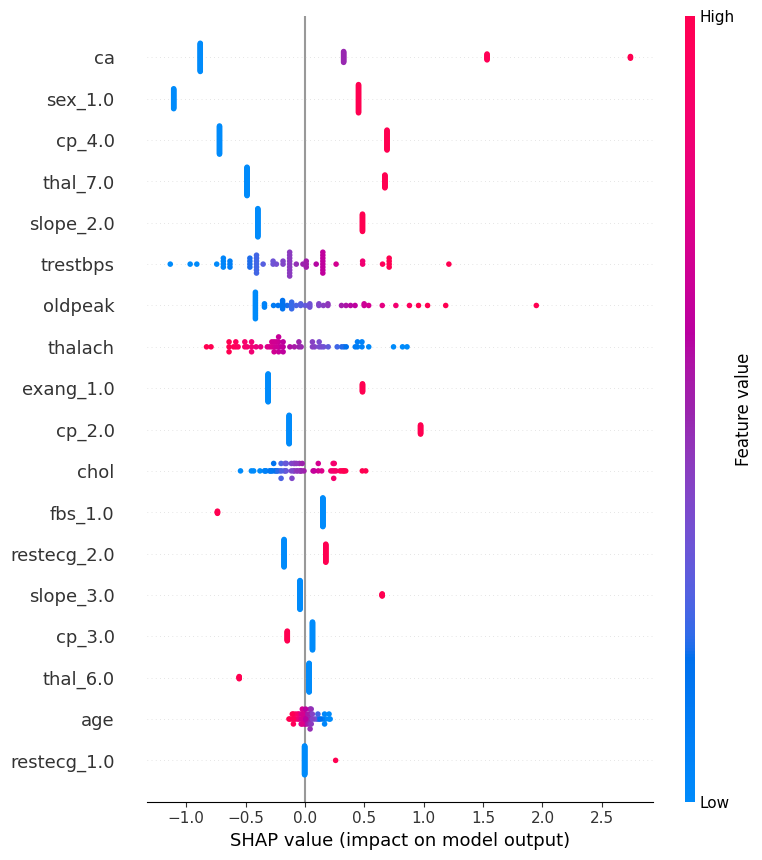

In [ ]:
!pip install shap
import shap

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, feature_names=X.columns)

## 5. Conclusion & Clinical Insights

**Key Insights:**
* **Statistical Drivers:** Coefficients identify **Major Vessels (ca)** and **Asymptomatic Chest Pain (cp_4.0)** as the primary predictors of disease.
* **Explainable AI (XAI):** The **SHAP summary plot** validates these findings, showing a clear positive correlation between vessel blockage and heart disease risk across the entire patient cohort.
* **Clinical Alignment:** The negative SHAP values for **Max Heart Rate (thalach)** align with cardiovascular fitness markers, proving the model is learning physiological signals rather than random noise.
